In [7]:
import os
import influxtools as it
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#from Wavemeter_1.Wavemeter_21_05_2nd_trial import df_faults

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
})

it.set_token(os.environ["INFLUX_TOKEN"])  # export INFLUX_TOKEN before running

FIGSIZE = (6.5, 3)
ALPHA_ITE = 1
LW_TEMP = 1.2
LW_ITE = 1.5
LS_TEMP = '--'
LS_ITE = '-'

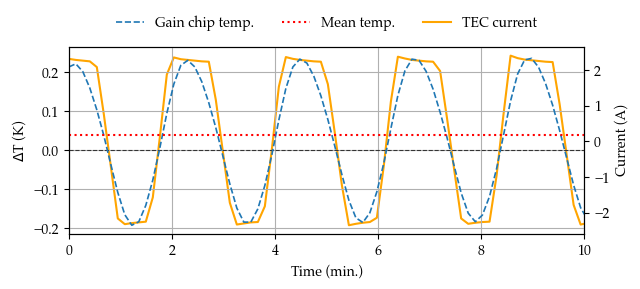

In [8]:
df_temp_P = it.get_data("VECSEL(next)", ["Gain chip temp."], start="2026-07-13 09:25:00", stop="2026-07-13 10:25:00")
df_ITE_P = it.get_data("VECSEL(next)", ["Gain chip ITE"], start="2026-07-13 09:25:00", stop="2026-07-13 10:25:00")

temp_P_set = 23

df_temp_P["Gain chip temp."] = df_temp_P["Gain chip temp."] - temp_P_set
temp_P_mean = df_temp_P["Gain chip temp."].mean()

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)

ax2.plot(df_ITE_P["time_s"] / 60, df_ITE_P["Gain chip ITE"], label="TEC current", color='orange', alpha=ALPHA_ITE, linewidth=LW_ITE, linestyle=LS_ITE)
ax2.set_ylabel("Current (A)")

ax1.plot(df_temp_P["time_s"] / 60, df_temp_P["Gain chip temp."], label="Gain chip temp.", linewidth=LW_TEMP, linestyle=LS_TEMP)
ax1.axhline(temp_P_mean, color='r', linestyle=':', label=f'Mean temp.')
ax1.set_ylabel(r"$\Delta$T (K)")
ax1.set_xlabel("Time (min.)")
ax1.set_xlim(0, 10)
ax1.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_lines, all_labels = lines1 + lines2, labels1 + labels2
ax1.legend(all_lines, all_labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=len(all_lines), frameon=False)

plt.tight_layout()

#plt.savefig("fig/PID_P_hi.png", dpi=300, bbox_inches='tight')
plt.savefig("fig/pid_P_hi.pdf", bbox_inches='tight')
plt.show()

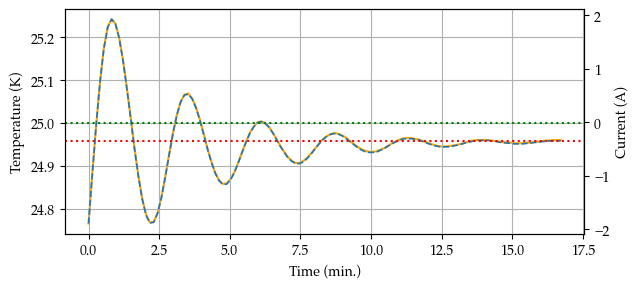

In [9]:
df_temp_midP = it.get_data("VECSEL(next)", ["Gain chip temp."], start="2026-07-13 10:31:10", stop="2026-07-13 10:48:00")
df_ITE_midP = it.get_data("VECSEL(next)", ["Gain chip ITE"], start="2026-07-13 10:31:10", stop="2026-07-13 10:48:00")

temp_midP_mean = df_temp_midP["Gain chip temp."].mean()
temp_midP_set = 25

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax2.plot(df_ITE_midP["time_s"] / 60, df_ITE_midP["Gain chip ITE"], label="Gain chip ITE", color='orange', alpha=ALPHA_ITE, linewidth=LW_ITE, linestyle=LS_ITE)
ax2.set_ylabel("Current (A)")

ax1.plot(df_temp_midP["time_s"] / 60, df_temp_midP["Gain chip temp."], label="Gain chip temp.", linewidth=LW_TEMP, linestyle=LS_TEMP)
ax1.axhline(temp_midP_mean, color='r', linestyle=':', label=f'Mean: {temp_midP_mean:.2f} K')
ax1.axhline(temp_midP_set, color='g', linestyle=':', label=f'Setpoint: {temp_midP_set} K')
ax1.set_ylabel("Temperature (K)")
ax1.set_xlabel("Time (min.)")
#ax1.set_xlim(0, 5000)
ax1.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_lines, all_labels = lines1 + lines2, labels1 + labels2
#ax1.legend(all_lines, all_labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=len(all_lines), frameon=False)

plt.tight_layout()

plt.savefig("fig/PID_P_mid.png", dpi=300, bbox_inches='tight')
plt.savefig("fig/PID_P_mid.pdf", bbox_inches='tight')
plt.show()

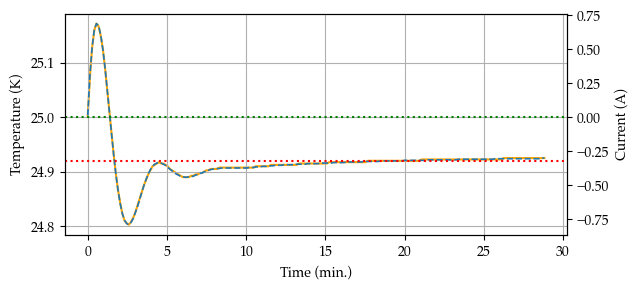

In [10]:
df_temp_lowP = it.get_data("VECSEL(next)", ["Gain chip temp."], start="2026-07-13 11:01:00", stop="2026-07-13 11:30:00")
df_ITE_lowP = it.get_data("VECSEL(next)", ["Gain chip ITE"], start="2026-07-13 11:01:00", stop="2026-07-13 11:30:00")

temp_lowP_mean = df_temp_lowP["Gain chip temp."].mean()
temp_lowP_set = 25

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax2.plot(df_ITE_lowP["time_s"] / 60, df_ITE_lowP["Gain chip ITE"], label="Gain chip ITE", color='orange', alpha=ALPHA_ITE, linewidth=LW_ITE, linestyle=LS_ITE)
ax2.set_ylabel("Current (A)")

ax1.plot(df_temp_lowP["time_s"] / 60, df_temp_lowP["Gain chip temp."], label="Gain chip temp.", linewidth=LW_TEMP, linestyle=LS_TEMP)
ax1.axhline(temp_lowP_mean, color='r', linestyle=':', label=f'Mean: {temp_lowP_mean:.2f} K')
ax1.axhline(temp_lowP_set, color='g', linestyle=':', label=f'Setpoint: {temp_lowP_set} K')
ax1.set_ylabel("Temperature (K)")
ax1.set_xlabel("Time (min.)")
#ax1.set_xlim(0, 5000)
ax1.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_lines, all_labels = lines1 + lines2, labels1 + labels2
#ax1.legend(all_lines, all_labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=len(all_lines), frameon=False)

plt.tight_layout()
plt.savefig("fig/PID_P_low.png", dpi=300, bbox_inches='tight')
plt.savefig("fig/PID_P_low.pdf", bbox_inches='tight')
plt.show()

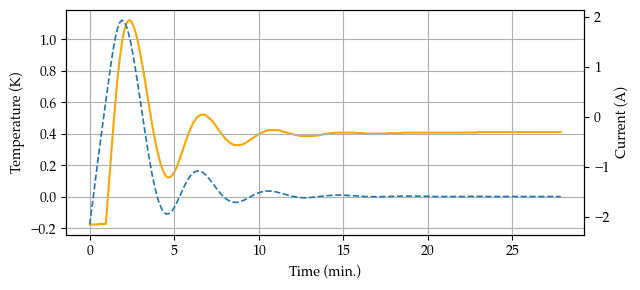

In [11]:
df_temp_I = it.get_data("VECSEL(next)", ["Gain chip temp."], start="2026-07-13 12:37:00", stop="2026-07-13 13:05:00")
df_ITE_I = it.get_data("VECSEL(next)", ["Gain chip ITE"], start="2026-07-13 12:37:00", stop="2026-07-13 13:05:00")

temp_I_set = 25
df_temp_I["Gain chip temp."] = df_temp_I["Gain chip temp."] - temp_I_set

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax2.plot(df_ITE_I["time_s"] / 60, df_ITE_I["Gain chip ITE"], label="Gain chip ITE", color='orange', alpha=ALPHA_ITE, linewidth=LW_ITE, linestyle=LS_ITE)
ax2.set_ylabel("Current (A)")

ax1.plot(df_temp_I["time_s"] / 60, df_temp_I["Gain chip temp."], label="Gain chip temp.", linewidth=LW_TEMP, linestyle=LS_TEMP)
#ax1.axhline(temp_I_mean, color='r', linestyle=':', label=f'Mean: {temp_I_mean:.2f} K')
#ax1.axhline(temp_I_set, color='g', linestyle=':', label=f'Setpoint: {temp_I_set} K')
ax1.set_ylabel("Temperature (K)")
ax1.set_xlabel("Time (min.)")
#ax1.set_xlim(0, 5000)
ax1.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_lines, all_labels = lines1 + lines2, labels1 + labels2
#ax1.legend(all_lines, all_labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=len(all_lines), frameon=False)

plt.tight_layout()
plt.savefig("fig/PID_I.png", dpi=300, bbox_inches='tight')
plt.savefig("fig/PID_I.pdf", bbox_inches='tight')
plt.show()

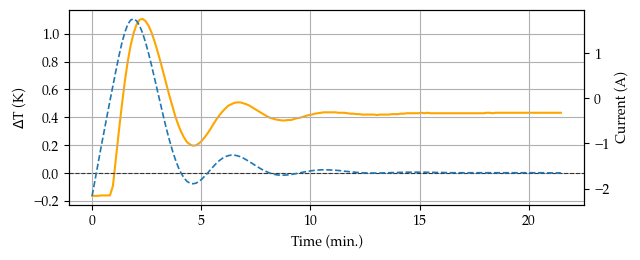

In [12]:
df_temp_D = it.get_data("VECSEL(next)", ["Gain chip temp."], start="2026-07-13 13:24:20", stop="2026-07-13 13:46:00")
df_ITE_D = it.get_data("VECSEL(next)", ["Gain chip ITE"], start="2026-07-13 13:24:20", stop="2026-07-13 13:46:00")

temp_D_set = 25

df_temp_D["Gain chip temp."] = df_temp_D["Gain chip temp."] - temp_D_set

fig, ax1 = plt.subplots(figsize=(6.5, 2.7))
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)

ax2.plot(df_ITE_D["time_s"] / 60, df_ITE_D["Gain chip ITE"], label="Gain chip ITE", color='orange', alpha=ALPHA_ITE, linewidth=LW_ITE, linestyle=LS_ITE)
ax2.set_ylabel("Current (A)")

ax1.plot(df_temp_D["time_s"] / 60, df_temp_D["Gain chip temp."], label="Gain chip temp.", linewidth=LW_TEMP, linestyle=LS_TEMP)
#ax1.axhline(temp_D_mean, color='r', linestyle=':', label=f'Mean: {temp_D_mean:.2f} K')
ax1.set_ylabel(r"$\Delta$T (K)")
ax1.set_xlabel("Time (min.)")
#ax1.set_xlim(0, 5000)
ax1.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_lines, all_labels = lines1 + lines2, labels1 + labels2
#ax1.legend(all_lines, all_labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=len(all_lines), frameon=False)

plt.tight_layout()
plt.savefig("fig/PID_D.png", dpi=300, bbox_inches='tight')
plt.savefig("fig/pid_D.pdf", bbox_inches='tight')
plt.show()